In [44]:
# import numpy as np
# import scipy
# import jax
# from jax import numpy as jnp
# from jax import random as jr
# from matplotlib import pyplot as plt
# import pickle as pkl
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=16)

# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

# from tqdm import tqdm

# prng_key = jr.PRNGKey(0)
# num_repeat = 1_000_000
# batch_sizes = [500000, 50000, 5000, 500, 500] # 2, 3, 4, 5, 6
# Ms = np.logspace(2,6,201, dtype=int)
# print(Ms)
# all_montecarlos = None
# for ii, M in enumerate(tqdm(Ms)):
#     mcs = np.array([])
#     batch_size = batch_sizes[int(np.log10(M))-2]
#     for ii in range(0, num_repeat, batch_size):
#         prng_key, _ = jr.split(prng_key)
#         xi = 2*jr.exponential(prng_key, shape=(M,batch_size))
#         montecarlo = jnp.mean(2*jnp.exp(-xi / 2), axis=0) ** (-100)
#         mcs = np.append(mcs, np.array(montecarlo))
#     if all_montecarlos is None:
#         all_montecarlos = mcs[:,None]
#     else:
#         all_montecarlos = np.append(all_montecarlos, mcs[:,None], axis=1)

# with open('exponential_montecarlos.pkl', 'wb') as ff:
#     pkl.dump(all_montecarlos, ff)

import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
import math
# from scipy.special import logsumexp as LSE
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib import patches
from matplotlib import text as mtext

class CurvedText(mtext.Text):
    """
    A text object that follows an arbitrary curve.
    """
    def __init__(self, x, y, text, axes, latex=False, **kwargs):
        super(CurvedText, self).__init__(x[0],y[0],' ', **kwargs)

        axes.add_artist(self)

        ##saving the curve:
        self.__x = x
        self.__y = y
        self.__zorder = self.get_zorder()

        ##creating the text objects
        self.__Characters = []
        if latex:
            c = text
            if c == ' ':
                ##make this an invisible 'a':
                t = mtext.Text(0,0,'a')
                t.set_alpha(0.0)
            else:
                t = mtext.Text(0,0,c, **kwargs)

            #resetting unnecessary arguments
            t.set_ha('center')
            t.set_rotation(0)
            t.set_zorder(self.__zorder +1)

            self.__Characters.append((c,t))
            axes.add_artist(t)
        else:
            for c in text:
                if c == ' ':
                    ##make this an invisible 'a':
                    t = mtext.Text(0,0,'a')
                    t.set_alpha(0.0)
                else:
                    t = mtext.Text(0,0,c, **kwargs)

                #resetting unnecessary arguments
                t.set_ha('center')
                t.set_rotation(0)
                t.set_zorder(self.__zorder +1)

                self.__Characters.append((c,t))
                axes.add_artist(t)


    ##overloading some member functions, to assure correct functionality
    ##on update
    def set_zorder(self, zorder):
        super(CurvedText, self).set_zorder(zorder)
        self.__zorder = self.get_zorder()
        for c,t in self.__Characters:
            t.set_zorder(self.__zorder+1)

    def draw(self, renderer, *args, **kwargs):
        """
        Overload of the Text.draw() function. Do not do
        do any drawing, but update the positions and rotation
        angles of self.__Characters.
        """
        self.update_positions(renderer)

    def update_positions(self,renderer):
        """
        Update positions and rotations of the individual text elements.
        """

        #preparations

        ##determining the aspect ratio:
        ##from https://stackoverflow.com/a/42014041/2454357

        ##data limits
        xlim = self.axes.get_xlim()
        ylim = self.axes.get_ylim()
        ## Axis size on figure
        figW, figH = self.axes.get_figure().get_size_inches()
        ## Ratio of display units
        _, _, w, h = self.axes.get_position().bounds
        ##final aspect ratio
        aspect = ((figW * w)/(figH * h))*(ylim[1]-ylim[0])/(xlim[1]-xlim[0])

        #points of the curve in figure coordinates:
        x_fig,y_fig = (
            np.array(l) for l in zip(*self.axes.transData.transform([
            (i,j) for i,j in zip(self.__x,self.__y)
            ]))
        )

        #point distances in figure coordinates
        x_fig_dist = (x_fig[1:]-x_fig[:-1])
        y_fig_dist = (y_fig[1:]-y_fig[:-1])
        r_fig_dist = np.sqrt(x_fig_dist**2+y_fig_dist**2)

        #arc length in figure coordinates
        l_fig = np.insert(np.cumsum(r_fig_dist),0,0)

        #angles in figure coordinates
        rads = np.arctan2((y_fig[1:] - y_fig[:-1]),(x_fig[1:] - x_fig[:-1]))
        degs = np.rad2deg(rads)


        rel_pos = 10
        for c,t in self.__Characters:
            #finding the width of c:
            t.set_rotation(0)
            t.set_va('center')
            bbox1  = t.get_window_extent(renderer=renderer)
            w = bbox1.width
            h = bbox1.height

            #ignore all letters that don't fit:
            if rel_pos+w/2 > l_fig[-1]:
                t.set_alpha(0.0)
                rel_pos += w
                continue

            elif c != ' ':
                t.set_alpha(1.0)

            #finding the two data points between which the horizontal
            #center point of the character will be situated
            #left and right indices:
            il = np.where(rel_pos+w/2 >= l_fig)[0][-1]
            ir = np.where(rel_pos+w/2 <= l_fig)[0][0]

            #if we exactly hit a data point:
            if ir == il:
                ir += 1

            #how much of the letter width was needed to find il:
            used = l_fig[il]-rel_pos
            rel_pos = l_fig[il]

            #relative distance between il and ir where the center
            #of the character will be
            fraction = (w/2-used)/r_fig_dist[il]

            ##setting the character position in data coordinates:
            ##interpolate between the two points:
            x = self.__x[il]+fraction*(self.__x[ir]-self.__x[il])
            y = self.__y[il]+fraction*(self.__y[ir]-self.__y[il])

            #getting the offset when setting correct vertical alignment
            #in data coordinates
            t.set_va(self.get_va())
            bbox2  = t.get_window_extent(renderer=renderer)

            bbox1d = self.axes.transData.inverted().transform(bbox1)
            bbox2d = self.axes.transData.inverted().transform(bbox2)
            dr = np.array(bbox2d[0]-bbox1d[0])

            #the rotation/stretch matrix
            rad = rads[il]
            rot_mat = np.array([
                [math.cos(rad), math.sin(rad)*aspect],
                [-math.sin(rad)/aspect, math.cos(rad)]
            ])

            ##computing the offset vector of the rotated character
            drp = np.dot(dr,rot_mat)

            #setting final position and rotation:
            t.set_position(np.array([x,y])+drp)
            t.set_rotation(degs[il])

            t.set_va('center')
            t.set_ha('center')

            #updating rel_pos to right edge of character
            rel_pos += w-used

colors = ["#000000","#b00069",'#00B862',"#0d2ec1",'#F7005A']

In [36]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

Ms = np.logspace(2,6,201, dtype=int)
num_repeat = 1_000_000
with open('../../../data/likelihood_bias/exponential_montecarlos.pkl', 'rb') as ff:
    all_montecarlos = pkl.load(ff)

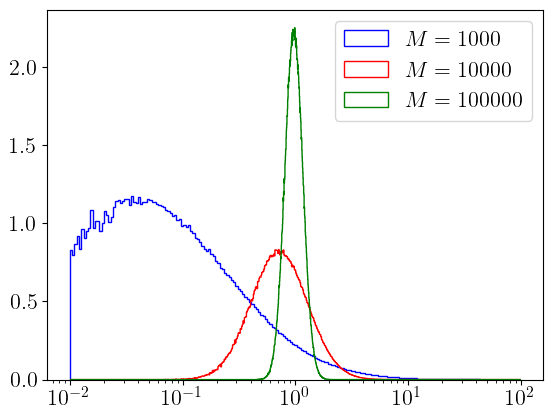

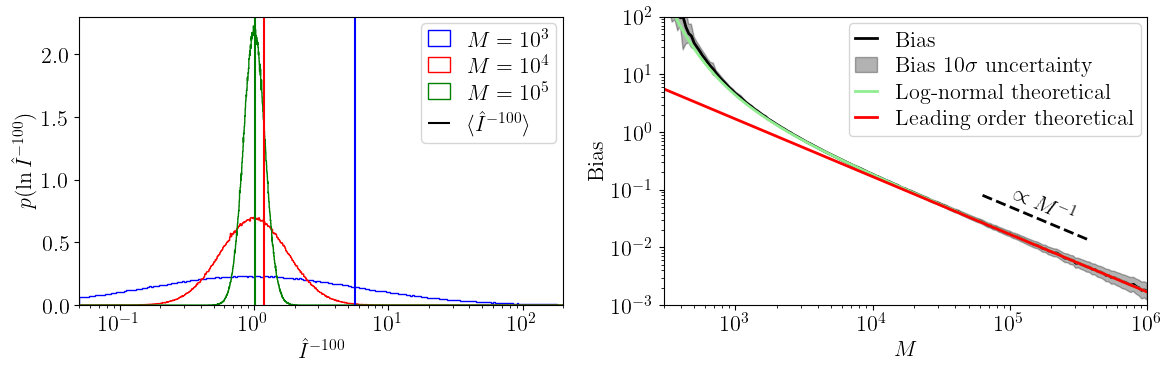

In [53]:
biases = np.mean(all_montecarlos, axis=0) - 1
uncertainties = np.std(all_montecarlos, axis=0) / np.sqrt(num_repeat)
stds = np.std(all_montecarlos, axis=0)
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')

plt.hist(all_montecarlos[:,50], bins=np.logspace(-2,2,200), histtype='step', density=True, color='b', label=f'$M={Ms[50]}$')
plt.hist(all_montecarlos[:,100], bins=np.logspace(-2,2,650), histtype='step', density=True, color='r', label=f'$M={Ms[100]}$')
plt.hist(all_montecarlos[:,150], bins=np.logspace(-2,2,2000), histtype='step', density=True, color='g', label=f'$M={Ms[150]}$')

plt.xscale('log')
plt.legend()
plt.show()

fig, ax = plt.subplots(ncols=2, figsize=(12,4))
Nsigma = 10
# xmin, xmax = 0, 7
# ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[0]+1))}$')
# ax[0].hist(all_montecarlos[:,50], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
# ax[0].hist(all_montecarlos[:,-1], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[-1]+1))}$')
xmin, xmax = 5e-2, 2e2
ax[0].hist(np.log(all_montecarlos[:,50]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),250)), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
ax[0].hist(np.log(all_montecarlos[:,100]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),700)), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[100]+1))}$')
ax[0].hist(np.log(all_montecarlos[:,150]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),2500)), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[150]+1))}$')
xticks = np.array([5e-3,6e-3,7e-3,8e-3,9e-3,1e-2,2e-2,3e-2,4e-2,5e-2,6e-2,7e-2,8e-2,9e-2,1e-1,2e-1,3e-1,4e-1,5e-1,6e-1,7e-1,8e-1,9e-1,1e0,2e0,3e0,4e0,5e0,6e0,7e0,8e0,9e0,1e1,2e1])*10
major_xticks = np.array([1e-2,1e-1,1e0,1e1])*10
ax[0].set_xticks(np.log(xticks), minor=True)
ax[0].set_xticks(np.log(major_xticks), ['$10^{-1}$', '$10^{0}$', '$10^{1}$', '$10^{2}$'])


ymin, ymax = 0, 2.3
ax[0].vlines(np.log(np.mean(all_montecarlos[:,50])), ymin, ymax, color='b')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,100])), ymin, ymax, color='r')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,150])), ymin, ymax, color='g')
ax[0].vlines(xmax + 2, ymin, ymax, color='k', label='$\\langle\hat{I}^{-100}\\rangle$')

ax[0].set_ylim([ymin, ymax])
ax[0].set_xlim([np.log(xmin), np.log(xmax)])
ax[0].set_ylabel('$p(\ln \hat{I}^{-100})$')
ax[0].set_xlabel('$\hat{I}^{-100}$')

# ax[0].legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)
ax[0].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

linewidth=2
alpha=1
lntheor = np.exp(5050 / 3 / Ms) - 1
# lntheor = (1 + 1 / 3 / Ms)**(5050) - 1 both are essentially equal
ax[1].plot(Ms, biases, 'k-', linewidth=linewidth, alpha=1, label='Bias')
ax[1].fill_between(Ms, biases*np.exp(-Nsigma*uncertainties/biases), biases*np.exp(Nsigma*uncertainties/biases), color='k', alpha=0.3, label=f'Bias ${Nsigma}\sigma$ uncertainty')
ax[1].plot(Ms, lntheor, linewidth=linewidth, alpha=alpha**0.5, linestyle='solid', color='lightgreen', label='Log-normal theoretical')
ax[1].plot(Ms, 5050 / 3 / Ms, 'r-', linewidth=linewidth, alpha=alpha, label='Leading order theoretical')
ax[1].plot(Ms[140:180], 5050 / Ms[140:180], 'k--', linewidth=linewidth, alpha=alpha)
CurvedText(x=Ms[148:180], y=1.3*5050 / Ms[148:180], text="$\propto M^{-1}$", ha='center', va='bottom', axes=ax[1], latex=True) #""

ax[1].set_xlim([300, Ms[-1]])
ax[1].set_ylim([1e-3, 100])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('Bias')
ax[1].set_xlabel('$M$')
# ax[1].legend(frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3)
ax[1].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

plt.tight_layout()
plt.savefig('../../../draft/plots/exponetial_powers.pdf')
plt.show()

In [42]:
Ms[150]

100000

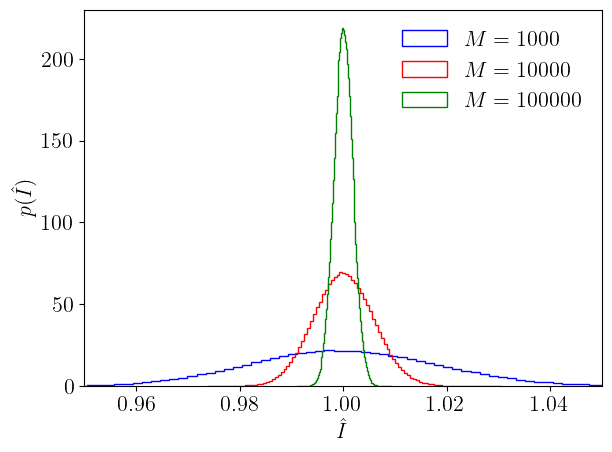

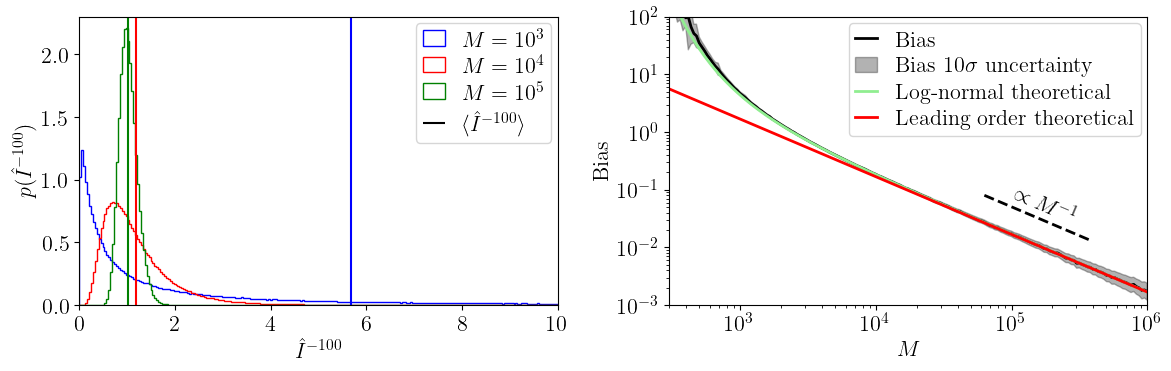

In [54]:

biases = np.mean(all_montecarlos, axis=0) - 1
uncertainties = np.std(all_montecarlos, axis=0) / np.sqrt(num_repeat)
stds = np.std(all_montecarlos, axis=0)
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')

plt.hist(all_montecarlos[:,50]**(1/100), bins=100, histtype='step', density=True, color='b', label=f'$M={Ms[50]}$')
plt.hist(all_montecarlos[:,100]**(1/100), bins=100, histtype='step', density=True, color='r', label=f'$M={Ms[100]}$')
plt.hist(all_montecarlos[:,150]**(1/100), bins=100, histtype='step', density=True, color='g', label=f'$M={Ms[150]}$')

plt.xlabel('$\hat{I}$')
plt.ylabel('$p(\hat{I})$')

plt.xlim(0.95,1.05)
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig('../../../draft/plots/poster_expo_ninj.pdf')
plt.show()

fig, ax = plt.subplots(ncols=2, figsize=(12,4))
Nsigma = 10
# xmin, xmax = 0, 7
# ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[0]+1))}$')
# ax[0].hist(all_montecarlos[:,50], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
# ax[0].hist(all_montecarlos[:,-1], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[-1]+1))}$')
xmin, xmax = 0, 10
ax[0].hist(all_montecarlos[:,50], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
ax[0].hist(all_montecarlos[:,100], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[100]+1))}$')
ax[0].hist(all_montecarlos[:,150], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[150]+1))}$')

ymin, ymax = 0, 2.3
ax[0].vlines(np.mean(all_montecarlos[:,50]), ymin, ymax, color='b')
ax[0].vlines(np.mean(all_montecarlos[:,100]), ymin, ymax, color='r')
ax[0].vlines(np.mean(all_montecarlos[:,150]), ymin, ymax, color='g')
ax[0].vlines(xmax + 2, ymin, ymax, color='k', label='$\\langle\hat{I}^{-100}\\rangle$')

ax[0].set_ylim([ymin, ymax])
ax[0].set_xlim([xmin, xmax])
ax[0].set_ylabel('$p(\hat{I}^{-100})$')
ax[0].set_xlabel('$\hat{I}^{-100}$')
# ax[0].set_yscale('log')
# ax[0].legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)
ax[0].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

linewidth=2
alpha=1
lntheor = np.exp(5050 / 3 / Ms) - 1
# lntheor = (1 + 1 / 3 / Ms)**(5050) - 1 both are essentially equal
ax[1].plot(Ms, biases, 'k-', linewidth=linewidth, alpha=1, label='Bias')
ax[1].fill_between(Ms, biases*np.exp(-Nsigma*uncertainties/biases), biases*np.exp(Nsigma*uncertainties/biases), color='k', alpha=0.3, label=f'Bias ${Nsigma}\sigma$ uncertainty')
ax[1].plot(Ms, lntheor, linewidth=linewidth, alpha=alpha**0.5, linestyle='solid', color='lightgreen', label='Log-normal theoretical')
ax[1].plot(Ms, 5050 / 3 / Ms, 'r-', linewidth=linewidth, alpha=alpha, label='Leading order theoretical')
ax[1].plot(Ms[140:180], 5050 / Ms[140:180], 'k--', linewidth=linewidth, alpha=alpha)
CurvedText(x=Ms[148:180], y=1.3*5050 / Ms[148:180], text="$\propto M^{-1}$", ha='center', va='bottom', axes=ax[1], latex=True) #""

ax[1].set_xlim([300, Ms[-1]])
ax[1].set_ylim([1e-3, 100])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('Bias')
ax[1].set_xlabel('$M$')
# ax[1].legend(frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3)
ax[1].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

plt.tight_layout()
plt.savefig('../../../draft/plots/exponetial_powers_hist_linscale.pdf')
plt.show()

array([5.00000000e-03, 9.98025575e-03, 1.99211009e-02, 3.97635364e-02,
       7.93700526e-02, 1.58426685e-01, 3.16227766e-01, 6.31206796e-01,
       1.25992105e+00, 2.51486686e+00, 5.01980288e+00, 1.00197833e+01,
       2.00000000e+01])

In [1]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)
from jax.interpreters import xla

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

prng_key = jr.PRNGKey(0)
larger_batch = 10
num_repeat = 1_000_000_000
batch_sizes = [500000, 50000, 5000, 2000, 500] # 2, 3, 4, 5, 6
Ms = np.logspace(2,4,101, dtype=int)
MMs = Ms[:,None] * np.ones(larger_batch, dtype=int)[None,:]
# MMs = Ms
MMs = MMs.flatten()
Ms_small = Ms
Nobs = 100
all_montecarlos = None

gpus = jax.devices('gpu')
cpus = jax.devices('cpu')

m1s = []
stds = []
@jax.jit
def moments(arr):
    return jnp.mean(arr), jnp.exp(LSE(2*jnp.log(arr)) - jnp.log(arr.size))

ms_tqdm = tqdm(Ms_small)
for ii, M in enumerate(ms_tqdm):
    
    m1 = 0.
    m2 = 0.
    batch_size = batch_sizes[int(np.log10(M))-2]
    
    # batch_size = 500
    @jax.jit
    def draw_mc(prng_key):
        xi = 2*jr.exponential(prng_key, shape=(M,))
        means = jnp.mean(2*jnp.exp(-xi / 2))
        variances = jnp.var(2*jnp.exp(-xi / 2)) / (M - 1)
        montecarlo = means ** (-Nobs) * jnp.exp((-Nobs*(Nobs+1)/2)*(variances/means**2))
        return jax.device_put(montecarlo, device=cpus[0])
        # return montecarlo
    
    mc_batch = jax.vmap(draw_mc)
    # for ik in range(50):
    #   montecarlo = jnp.array([])
    ranger = int(num_repeat / batch_size)
    def loop_fn(_, val):
        prng_key, m1, m2 = val
        prng_key, _ = jr.split(prng_key)
        prng_keys = jr.split(prng_key, batch_size)
        montecarlo, second_moment = moments(mc_batch(prng_keys))
        m1 += montecarlo 
        m2 += second_moment
        return prng_key, m1, m2
    prng_key, m1, m2 = jax.lax.fori_loop(0, ranger, loop_fn, (prng_key, m1, m2))
        
        # montecarlo = jax.device_put(montecarlo, cpus[0])
        
        # if int(ij/batch_size) % 50 == 0:
        #     # print('cleared cache')
        #     jax.clear_caches()
    # else:
    #     all_montecarlos = np.append(all_montecarlos, mcs.flatten()[:,None], axis=1)
    mean = m1 / ranger
    m2_mean = m2 / ranger
    std = np.sqrt((m2_mean - mean**2)) / np.sqrt(num_repeat - 1)
    m1s.append(mean)
    stds.append(std)
    ms_tqdm.set_description(f'M = {M}, mean = {mean} +/- {std}')

with open('exponential_montecarlo_means.pkl', 'wb') as ff:
    pkl.dump((m1s, stds), ff)


M = 10000, mean = 0.9994287490844727 +/- 1.9919847903217677e-05: 100%|██████████| 101/101 [1:15:11<00:00, 44.67s/it] 


In [ ]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)
from jax.interpreters import xla

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

prng_key = jr.PRNGKey(0)
larger_batch = 10
num_repeat = 1_000_000_000
batch_sizes = [500000, 50000, 5000, 2000, 500] # 2, 3, 4, 5, 6
Ms = np.logspace(4,5,51, dtype=int)
MMs = Ms[:,None] * np.ones(larger_batch, dtype=int)[None,:]
# MMs = Ms
MMs = MMs.flatten()
Ms_small = Ms
Nobs = 100
all_montecarlos = None
from jax_tqdm import loop_tqdm
gpus = jax.devices('gpu')
cpus = jax.devices('cpu')

m1s = []
stds = []
@jax.jit
def moments(arr):
    return jnp.mean(arr), jnp.exp(LSE(2*jnp.log(arr)) - jnp.log(arr.size))

ms_tqdm = Ms_small
for ii, M in enumerate(ms_tqdm):
    
    m1 = 0.
    m2 = 0.
    batch_size = batch_sizes[int(np.log10(M))-2]
    
    # batch_size = 500
    @jax.jit
    def draw_mc(prng_key):
        xi = 2*jr.exponential(prng_key, shape=(M,))
        means = jnp.mean(2*jnp.exp(-xi / 2))
        variances = jnp.var(2*jnp.exp(-xi / 2)) / (M - 1)
        montecarlo = means ** (-Nobs) * jnp.exp((-Nobs*(Nobs+1)/2)*(variances/means**2))
        return montecarlo
        # return montecarlo
    
    mc_batch = jax.vmap(draw_mc)
    # for ik in range(50):
    #   montecarlo = jnp.array([])
    ranger = int(num_repeat / batch_size)
    
    @loop_tqdm(ranger, print_rate=1, tqdm_type='auto')
    def loop_fn(_, val):
        prng_key, m1, m2 = val
        prng_key, _ = jr.split(prng_key)
        prng_keys = jr.split(prng_key, batch_size)
        montecarlo, second_moment = moments(mc_batch(prng_keys))
        m1 += montecarlo 
        m2 += second_moment
        return prng_key, m1, m2

    prng_key, m1, m2 = jax.lax.fori_loop(0, ranger, loop_fn, (prng_key, m1, m2))
        
        # montecarlo = jax.device_put(montecarlo, cpus[0])
        
        # if int(ij/batch_size) % 50 == 0:
        #     # print('cleared cache')
        #     jax.clear_caches()
    # else:
    #     all_montecarlos = np.append(all_montecarlos, mcs.flatten()[:,None], axis=1)
    mean = m1 / ranger
    m2_mean = m2 / ranger
    std = np.sqrt((m2_mean - mean**2)) / np.sqrt(num_repeat - 1)
    m1s.append(mean)
    stds.append(std)
    # ms_tqdm.set_description()
    print(f'M = {M}, mean = {mean} +/- {std}')
with open('exponential_montecarlo_means_4_to_5.pkl', 'wb') as ff:
    pkl.dump((m1s, stds), ff)


In [13]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)
from jax.interpreters import xla

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

prng_key = jr.PRNGKey(0)
larger_batch = 10
num_repeat = 1_000_000
batch_sizes = [500000, 50000, 5000, 2000, 500] # 2, 3, 4, 5, 6
Ms = np.array([1000, 10000, 100000])
Nobs = 100
all_montecarlos = None

ms_tqdm = Ms
for ii, M in enumerate(ms_tqdm):
    
    mcs = np.array([])
    batch_size = batch_sizes[int(np.log10(M))-2]
    
    @jax.jit
    def draw_mc(prng_key):
        xi = 2*jr.exponential(prng_key, shape=(M,))
        means = jnp.mean(2*jnp.exp(-xi / 2))
        variances = jnp.var(2*jnp.exp(-xi / 2)) / (M - 1)
        montecarlo = means ** (-Nobs) * jnp.exp((-Nobs*(Nobs+1)/2)*(variances/means**2))
        return montecarlo
    
    mc_batch = jax.vmap(draw_mc)
    ranger = int(num_repeat / batch_size)
    
    for ii  in tqdm(range(ranger)):

        prng_key, _ = jr.split(prng_key)
        prng_keys = jr.split(prng_key, batch_size)
        montecarlo = mc_batch(prng_keys)

        mcs = np.append(mcs, np.array(montecarlo))

    if all_montecarlos is None:
        all_montecarlos = mcs[:,None]
    else:
        all_montecarlos = np.append(all_montecarlos, mcs[:,None], axis=1)
    

with open('exponential_montecarlo_for_plot.pkl', 'wb') as ff:
    pkl.dump(all_montecarlos, ff)


100%|██████████| 500/500 [00:05<00:00, 93.78it/s] 


In [11]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)
from jax.interpreters import xla

import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '3'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm

with open('../../../data/likelihood_bias/exponential_montecarlo_means.pkl', 'rb') as ff:
    m1s_pkl, stds_pkl = pkl.load(ff)

with open('../../../data/likelihood_bias/exponential_montecarlo_means_4_to_5.pkl', 'rb') as ff:
    m1s_4_to_5, stds_4_to_5 = pkl.load(ff)

m1s_pkl = np.array(m1s_pkl, dtype=float)
stds_pkl = np.array(stds_pkl, dtype=float)
m1s_4_to_5 = np.array(m1s_4_to_5, dtype=float)
stds_4_to_5 = np.array(stds_4_to_5, dtype=float)

num_success = 1

m1s_4_to_5 *= 0.
stds_4_to_5 *= 0.
num_success = 0

m2s_4_to_5 = (stds_4_to_5*np.sqrt(1e9))**2 + m1s_4_to_5**2

for ii in range(1,4):
    try:
        with open(f'../../../data/likelihood_bias/exponential_montecarlo_means_assistance_{ii}.pkl', 'rb') as ff:
            m1s_4_to_5_assist, stds_4_to_5_assist = pkl.load(ff)
        num_success += 3
        print(f'Using extra injection set {ii}')
    except:
        print(f'Extra injection set {ii} not completed yet')
        continue
    m1s_4_to_5 = (m1s_4_to_5 + 3*np.array(m1s_4_to_5_assist, dtype=float))
    m2s_4_to_5 = m2s_4_to_5 + 3*np.array(m1s_4_to_5_assist, dtype=float)**2 + 3*(np.array(stds_4_to_5_assist, dtype=float)*np.sqrt(1e9))**2

m1s_4_to_5 = m1s_4_to_5 / num_success
stds_4_to_5 = ((m2s_4_to_5 / num_success) - m1s_4_to_5**2) / np.sqrt(num_success * 1e9)

with open('../../../data/likelihood_bias/exponential_montecarlo_for_plot.pkl', 'rb') as ff:
    all_montecarlos = pkl.load(ff)

m1s = np.append(m1s_pkl, m1s_4_to_5[1:])
stds = np.append(stds_pkl, stds_4_to_5[1:])

num_repeat = 1_000_000_000 * num_success
batch_sizes = [500000, 50000, 5000, 2000, 500] # 2, 3, 4, 5, 6
Ms = np.logspace(2,5,151, dtype=int)
Nobs = 100

Using extra injection set 1
Using extra injection set 2
Using extra injection set 3


In [12]:
mmmm = np.logspace(4,5,51,dtype=int)
fourth_theor = 2*Nobs*(Nobs+1)*(2*Nobs + 3) / 8 / 9 / mmmm**2
wrongness = (1 - m1s_4_to_5) / fourth_theor

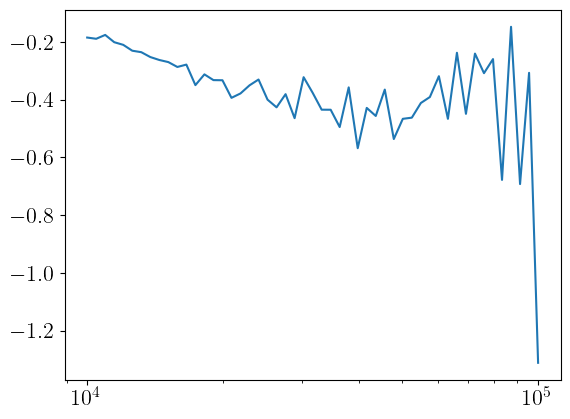

In [13]:
plt.plot(mmmm, np.log10(wrongness));
plt.xscale('log')

In [14]:
1-m1s_pkl, 1 - m1s_4_to_5

(array([9.81851354e-01, 9.85987116e-01, 9.80788760e-01, 9.52386104e-01,
        9.62509543e-01, 9.61341329e-01, 8.85747030e-01, 9.27786835e-01,
        7.84678653e-01, 8.94756310e-01, 8.68437871e-01, 8.61763731e-01,
        8.29746604e-01, 8.07387307e-01, 7.58888334e-01, 7.51769051e-01,
        7.20584154e-01, 6.82646304e-01, 6.48749739e-01, 6.22805595e-01,
        5.85353732e-01, 5.53095013e-01, 5.24810463e-01, 4.98826981e-01,
        4.65988100e-01, 4.30606663e-01, 4.03848529e-01, 3.71519327e-01,
        3.47542942e-01, 3.23724627e-01, 3.03270817e-01, 2.80040622e-01,
        2.59716272e-01, 2.38677442e-01, 2.21868873e-01, 2.04077125e-01,
        1.86903477e-01, 1.72800183e-01, 1.58182085e-01, 1.45786226e-01,
        1.34434819e-01, 1.23175740e-01, 1.12762511e-01, 1.03532732e-01,
        9.49863791e-02, 8.69566798e-02, 7.96778202e-02, 7.27864504e-02,
        6.63638115e-02, 6.08500242e-02, 5.55648208e-02, 5.09540439e-02,
        4.68994379e-02, 4.25031781e-02, 3.90819907e-02, 3.552132

In [5]:
x = 3.96364927e-04 / 5.71250916e-04
np.exp(x), np.sqrt(x)

(2.0014148180369133, 0.8329791951078863)

In [17]:
num_success

4

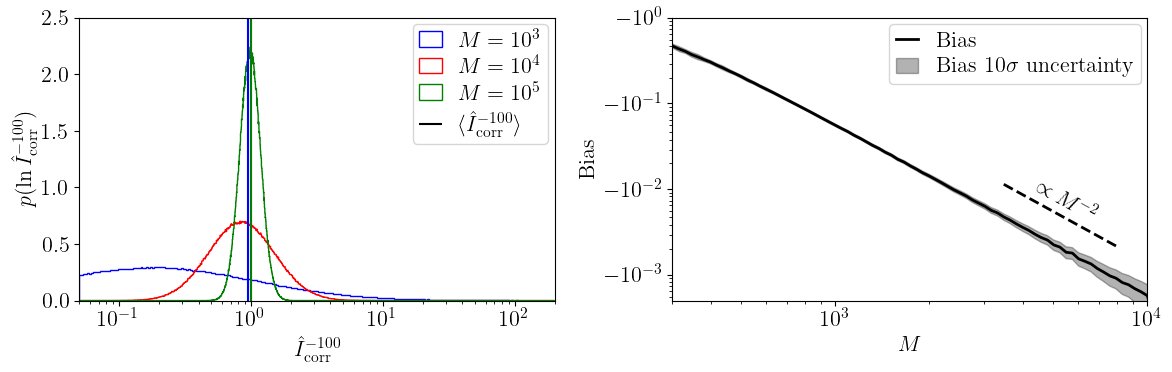

In [33]:
biases = 1 - m1s
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')
uncertainties = stds

fig, ax = plt.subplots(ncols=2, figsize=(12,4))
Nsigma = 10
xmin, xmax = 0, 7
# ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[0]+1))}$')
# ax[0].hist(all_montecarlos[:,1], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
# ax[0].hist(all_montecarlos[:,2], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[-1]+1))}$')
xmin, xmax = 5e-2, 2e2
ax[0].hist(np.log(all_montecarlos[:,0]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),250)), histtype='step', density=True, color='b', label=f'$M=10^{3}$')
ax[0].hist(np.log(all_montecarlos[:,1]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),650)), histtype='step', density=True, color='r', label=f'$M=10^{4}$')
ax[0].hist(np.log(all_montecarlos[:,2]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),2500)), histtype='step', density=True, color='g', label=f'$M=10^{5}$')

xticks = np.array([5e-3,6e-3,7e-3,8e-3,9e-3,1e-2,2e-2,3e-2,4e-2,5e-2,6e-2,7e-2,8e-2,9e-2,1e-1,2e-1,3e-1,4e-1,5e-1,6e-1,7e-1,8e-1,9e-1,1e0,2e0,3e0,4e0,5e0,6e0,7e0,8e0,9e0,1e1,2e1])*10
major_xticks = np.array([1e-2,1e-1,1e0,1e1])*10

ax[0].set_xticks(np.log(xticks), minor=True)
ax[0].set_xticks(np.log(major_xticks), ['$10^{-1}$', '$10^{0}$', '$10^{1}$', '$10^{2}$'])

ymin, ymax = 0, 2.5
ax[0].vlines(np.log(np.mean(all_montecarlos[:,0])), ymin, ymax, color='b')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,1])), ymin, ymax, color='r')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,2])), ymin, ymax, color='g')
ax[0].vlines(xmax + 2, ymin, ymax, color='k', label='$\\langle\hat{I}_{\\rm corr}^{-100}\\rangle$')

ax[0].set_ylim([ymin, ymax])
ax[0].set_xlim([np.log(xmin), np.log(xmax)])
ax[0].set_ylabel('$p(\ln \hat{I}_{\\rm corr}^{-100})$')
ax[0].set_xlabel('$\hat{I}_{\\rm corr}^{-100}$')

# ax[0].legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)
ax[0].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

linewidth=2
alpha=1
lntheor = np.exp(5050 / 3 / Ms) - 1
fourth_theor = 2*Nobs*(Nobs+1)*(2*Nobs + 3) / 8 / 9 / Ms / (Ms-1) # factor of 3 off. Am I counting the variance too many times?
# lntheor = (1 + 1 / 3 / Ms)**(5050) - 1 both are essentially equal
ax[1].plot(Ms, biases, 'k-', linewidth=linewidth, alpha=1, label='Bias')
uncertainties[27] = (uncertainties[26] + uncertainties[28])/2
ax[1].fill_between(Ms, biases-Nsigma*uncertainties, biases+Nsigma*uncertainties, color='k', alpha=0.3, label=f'Bias ${Nsigma}\sigma$ uncertainty')
# ax[1].plot(Ms, lntheor, linewidth=linewidth, alpha=alpha**0.5, linestyle='solid', color='lightgreen', label='Log-normal theoretical')
ax[1].plot(Ms[-74:-55], 2.4*fourth_theor[-74:-55], 'k--', linewidth=linewidth, alpha=alpha)# , label='Leading order theoretical')
# ax[1].plot(, 3*fourth_theor[-70:-60], 'k--', linewidth=linewidth, alpha=alpha)# , label='Leading order theoretical')
CurvedText(x=Ms[-70:-60], y=3*fourth_theor[-70:-60], text="$\propto M^{-2}$", ha='center', va='bottom', axes=ax[1], latex=True) #""

ax[1].set_xlim([300, Ms[-1]])
ax[1].set_ylim([1e-5, 1])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('Bias')
# ax[1].set_yticks([1e-5,1e-4,1e-3,1e-2,1e-1,1], ['','','','','',''], minor=True)
# ax[1].set_yticks([1e-5,1e-3,1e-1], ['$-10^{-5}$', '$-10^{-3}$', '$-10^{-1}$'])

ax[1].set_yticks(np.concatenate([
    np.linspace(1e-5,1e-4,11),
    np.linspace(2e-4,1e-3,10),
    np.linspace(2e-3,1e-2,10),
    np.linspace(2e-2,1e-1,10),
    np.linspace(2e-1,1e-0,10)
    ]),
    minor=True)
    
ax[1].set_yticks([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1], ['$-10^{-6}$', '$-10^{-5}$', '$-10^{-4}$', '$-10^{-3}$', '$-10^{-2}$', '$-10^{-1}$', '$-10^{0}$'])

ax[1].set_xlabel('$M$')
ax[1].set_ylim([5e-4,1])
ax[1].set_xlim([300, 1e4])
# ax[1].legend(frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3)
ax[1].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

plt.tight_layout()
plt.savefig('../../../draft/plots/exponetial_powers_corrected.pdf')
plt.show()


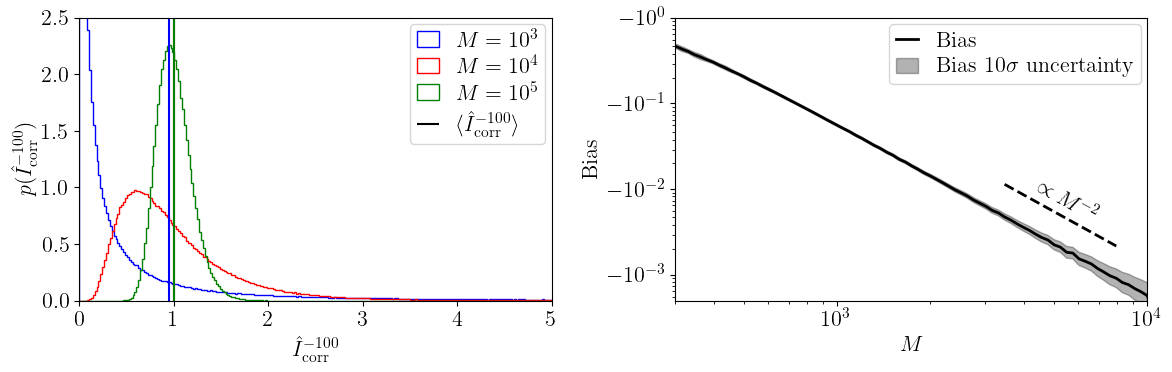

In [34]:
biases = np.abs(m1s - 1)
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')
uncertainties = stds

fig, ax = plt.subplots(ncols=2, figsize=(12,4))
Nsigma = 10
xmin, xmax = 0, 7
# ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[0]+1))}$')
# ax[0].hist(all_montecarlos[:,1], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
# ax[0].hist(all_montecarlos[:,2], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[-1]+1))}$')
xmin, xmax = 0, 5
ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='b', label=f'$M=10^{3}$')
ax[0].hist(all_montecarlos[:,1], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='r', label=f'$M=10^{4}$')
ax[0].hist(all_montecarlos[:,2], bins=np.linspace(xmin,xmax,250), histtype='step', density=True, color='g', label=f'$M=10^{5}$')

ymin, ymax = 0, 2.5
ax[0].vlines(np.mean(all_montecarlos[:,0]), ymin, ymax, color='b')
ax[0].vlines(np.mean(all_montecarlos[:,1]), ymin, ymax, color='r')
ax[0].vlines(np.mean(all_montecarlos[:,2]), ymin, ymax, color='g')
ax[0].vlines(xmax + 2, ymin, ymax, color='k', label='$\\langle\hat{I}_{\\rm corr}^{-100}\\rangle$')

ax[0].set_ylim([ymin, ymax])
ax[0].set_xlim([xmin, xmax])
ax[0].set_ylabel('$p(\hat{I}_{\\rm corr}^{-100})$')
ax[0].set_xlabel('$\hat{I}_{\\rm corr}^{-100}$')
# ax[0].set_yscale('log')
# ax[0].legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)
ax[0].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

linewidth=2
alpha=1
lntheor = np.exp(5050 / 3 / Ms) - 1
fourth_theor = Nobs*(Nobs+1)*(2*Nobs + 3) / 36 / Ms**2 

ax[1].plot(Ms, biases, 'k-', linewidth=linewidth, alpha=1, label='Bias')
ax[1].fill_between(Ms, biases*np.exp(-Nsigma*uncertainties/biases), biases*np.exp(Nsigma*uncertainties/biases), color='k', alpha=0.3, label=f'Bias ${Nsigma}\sigma$ uncertainty')
# ax[1].plot(Ms, lntheor, linewidth=linewidth, alpha=alpha**0.5, linestyle='solid', color='lightgreen', label='Log-normal theoretical')
# ax[1].plot(Ms, fourth_theor, 'r-', linewidth=linewidth, alpha=alpha, label='Leading order theoretical')
ax[1].plot(Ms[-74:-55], 2.4*fourth_theor[-74:-55], 'k--', linewidth=linewidth, alpha=alpha)# , label='Leading order theoretical')
# ax[1].plot(, 3*fourth_theor[-70:-60], 'k--', linewidth=linewidth, alpha=alpha)# , label='Leading order theoretical')
CurvedText(x=Ms[-70:-60], y=3*fourth_theor[-70:-60], text="$\propto M^{-2}$", ha='center', va='bottom', axes=ax[1], latex=True) #""

ax[1].set_xlim([300, Ms[-1]])
ax[1].set_ylim([1e-5, 1])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('Bias')
# ax[1].set_yticks([1e-5,1e-4,1e-3,1e-2,1e-1,1], ['','','','','',''], minor=True)
# ax[1].set_yticks([1e-5,1e-3,1e-1], ['$-10^{-5}$', '$-10^{-3}$', '$-10^{-1}$'])

ax[1].set_yticks(np.concatenate([
    np.linspace(1e-5,1e-4,11),
    np.linspace(2e-4,1e-3,10),
    np.linspace(2e-3,1e-2,10),
    np.linspace(2e-2,1e-1,10),
    np.linspace(2e-1,1e-0,10)
    ]),
    minor=True)
    
ax[1].set_yticks([1e-5,1e-4,1e-3,1e-2,1e-1,1], ['$-10^{-5}$', '$-10^{-4}$', '$-10^{-3}$', '$-10^{-2}$', '$-10^{-1}$', '$-10^{0}$'])

ax[1].set_xlabel('$M$')

ax[1].set_ylim([5e-4,1])
ax[1].set_xlim([300, 1e4])
# ax[1].legend(frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3)
ax[1].legend(loc='upper right', borderpad=0.3, labelspacing=0.3, columnspacing=0.5, handlelength=1, borderaxespad=0.3)

plt.tight_layout()
plt.savefig('../../../draft/plots/exponetial_powers_corrected_hist_linscale.pdf')
plt.show()


In [ ]:
biases = np.abs(m1s - 1)
plt.rc('text.latex', preamble=r'\usepackage{amsfonts}')
uncertainties = stds

fig, ax = plt.subplots(ncols=2, figsize=(12,4))
Nsigma = 10
xmin, xmax = 0, 7
# ax[0].hist(all_montecarlos[:,0], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='b', label=f'$M=10^{int(np.log10(Ms[0]+1))}$')
# ax[0].hist(all_montecarlos[:,1], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='r', label=f'$M=10^{int(np.log10(Ms[50]+1))}$')
# ax[0].hist(all_montecarlos[:,2], bins=np.linspace(xmin,xmax,200), histtype='step', density=True, color='g', label=f'$M=10^{int(np.log10(Ms[-1]+1))}$')
xmin, xmax = 5e-2, 2e2
ax[0].hist(np.log(all_montecarlos[:,0]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),250)), histtype='step', density=True, color='b', label=f'$M=10^{3}$')
ax[0].hist(np.log(all_montecarlos[:,1]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),250)), histtype='step', density=True, color='r', label=f'$M=10^{4}$')
ax[0].hist(np.log(all_montecarlos[:,2]), bins=np.log(np.logspace(np.log10(xmin),np.log10(xmax),250)), histtype='step', density=True, color='g', label=f'$M=10^{5}$')

xticks = np.array([5e-3,6e-3,7e-3,8e-3,9e-3,1e-2,2e-2,3e-2,4e-2,5e-2,6e-2,7e-2,8e-2,9e-2,1e-1,2e-1,3e-1,4e-1,5e-1,6e-1,7e-1,8e-1,9e-1,1e0,2e0,3e0,4e0,5e0,6e0,7e0,8e0,9e0,1e1,2e1])*10
major_xticks = np.array([1e-2,1e-1,1e0,1e1])*10

ax[0].set_xticks(np.log(xticks), minor=True)
ax[0].set_xticks(np.log(major_xticks), ['$10^{-1}$', '$10^{0}$', '$10^{1}$', '$10^{2}$'])

ymin, ymax = 0, 2.3
ax[0].vlines(np.log(np.mean(all_montecarlos[:,0])), ymin, ymax, color='b')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,1])), ymin, ymax, color='r')
ax[0].vlines(np.log(np.mean(all_montecarlos[:,2])), ymin, ymax, color='g')
ax[0].vlines(xmax + 2, ymin, ymax, color='k', label='$\\langle\hat{I}^{-100}\\rangle$')

ax[0].set_ylim([ymin, ymax])
ax[0].set_xlim([np.log(xmin), np.log(xmax)])
ax[0].set_ylabel('$p(\hat{I}^{-100})$')
ax[0].set_xlabel('$\hat{I}^{-100}$')

ax[0].legend(frameon=False, loc='upper right', borderpad=0.1, labelspacing=0.3)

linewidth=2
alpha=1
lntheor = np.exp(5050 / 3 / Ms) - 1
fourth_theor = 2*Nobs*(Nobs+1)*(2*Nobs + 3) / 8 / 9 / Ms / (Ms-1) # factor of 3 off. Am I counting the variance too many times?
# lntheor = (1 + 1 / 3 / Ms)**(5050) - 1 both are essentially equal
ax[1].plot(Ms, biases, 'k-', linewidth=linewidth, alpha=1, label='Bias')
ax[1].fill_between(Ms, biases*np.exp(-Nsigma*uncertainties/biases), biases*np.exp(Nsigma*uncertainties/biases), color='k', alpha=0.3, label=f'Bias ${Nsigma}\sigma$ uncertainty')
ax[1].plot(Ms, lntheor, linewidth=linewidth, alpha=alpha**0.5, linestyle='solid', color='lightgreen', label='Log-normal theoretical')
ax[1].plot(Ms, fourth_theor, 'r-', linewidth=linewidth, alpha=alpha, label='Leading order theoretical')

ax[1].set_xlim([300, Ms[-1]])
ax[1].set_ylim([1e-5, 10])
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_ylabel('Bias')
ax[1].set_xlabel('$M$')
ax[1].legend(frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3)
plt.tight_layout()
plt.savefig('../../../draft/plots/exponetial_powers_corrected.pdf')
plt.show()



In [14]:
np.exp(Nsigma*uncertainties/biases)

array([1.05149439, 1.01695513, 1.01872528, 1.16097185, 1.06428317,
       1.03236851, 1.69316906, 1.05796499, 3.75540733, 1.11782744,
       1.12912319, 1.05269635, 1.09142181, 1.07806088, 1.21003124,
       1.06867769, 1.15466096, 1.13198388, 1.10944055, 1.08230599,
       1.12685529, 1.10189321, 1.06930692, 1.04990385, 1.05599254,
       1.06856019, 1.05499713, 1.22593339, 1.07277601, 1.05187373,
       1.04655075, 1.0468682 , 1.05315809, 1.0450326 , 1.03640736,
       1.04160493, 1.04218828, 1.03532883, 1.03578836, 1.03931045,
       1.03254043, 1.03148437, 1.0312489 , 1.02963607, 1.02987964,
       1.02900634, 1.02916788, 1.03055354, 1.02995318, 1.03152619,
       1.03007385, 1.03016718, 1.03072367, 1.03159483, 1.03204572,
       1.03280695, 1.03391205, 1.03460302, 1.03600021, 1.03681994,
       1.03909486, 1.0396887 , 1.04170918, 1.0433629 , 1.0456966 ,
       1.04722099, 1.0494397 , 1.05188002, 1.05466748, 1.05773414,
       1.06015758, 1.06301836, 1.06750715, 1.07084159, 1.07422